In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.datasets import make_regression

In [65]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

Text(0, 0.5, 'y')

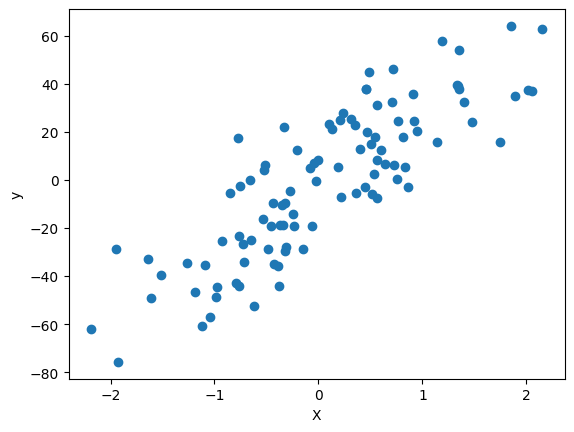

In [66]:
plt.Figure(figsize=(8, 6))
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')

In [67]:
from sklearn.linear_model import LinearRegression


In [68]:
lr  = LinearRegression()

lr.fit(X, y)

y_pred = lr.predict(X)

In [69]:
from sklearn.metrics import r2_score

print(f"R^2 Score: {r2_score(y, y_pred):.4f}")
print(f"Coefficients: {lr.coef_}")
print(f"Intercept: {lr.intercept_:.4f}")

R^2 Score: 0.7035
Coefficients: [27.82809103]
Intercept: -2.2947


In [70]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge.fit(X,y)
y_pred_r = ridge.predict(X)
print(f"Coefficients: {ridge.coef_}")
print(f"Intercept: {ridge.intercept_:.4f}")
print(f"R^2 Score: {r2_score(y, y_pred_r)*100}")

Coefficients: [24.9546267]
Intercept: -2.1269
R^2 Score: 69.60172225909294


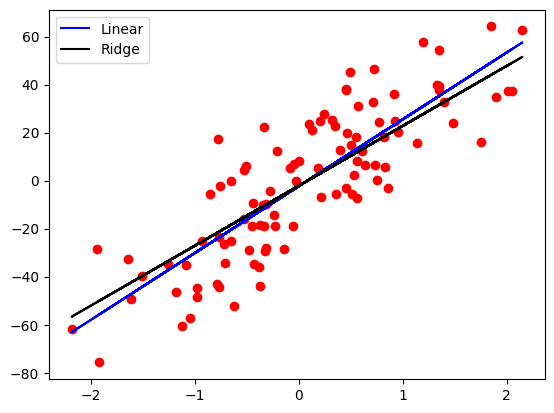

In [71]:
# sort_idx = np.argsort(X[:, 0])

plt.scatter(X, y, color="red")
plt.plot(X, lr.predict(X), color="blue", label="Linear")
plt.plot(X, ridge.predict(X), color="black", label="Ridge")

plt.legend()
plt.show()

Own Ridge Regression Class


In [72]:
class own_ridge_class:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X, y):

        X = X.flatten()

        num = 0
        deno = 0

        for i in range(X.shape[0]):
            num += (y[i] - y.mean()) * (X[i] - X.mean())
            deno += (X[i] - X.mean())**2

        self.m = num / (deno + self.alpha)
        self.b = y.mean() - self.m * X.mean()

        print(f"coefficient = {self.m}")
        print(f"intercept = {self.b}")

    def predict(self, X):

        X = X.flatten()

        return self.m * X + self.b

In [73]:
rr = own_ridge_class(alpha=10)
rr.fit(X,y)

coefficient = 24.954626701073426
intercept = -2.1269130035235735
